<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/phase3_step2_gnina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3, Step 2 — Blind Docking with GNINA
## AI Drug Discovery Pipeline · Insulin Receptor (INSR)

**Why GNINA instead of DiffDock?**  
GNINA is a deep learning docking tool (CNN scoring) that installs in one command — no weight downloads,
no authentication, no dependency hell. It is listed as a valid alternative in the Phase 3 pipeline spec
and produces comparable pose quality for allosteric pocket recovery.

**Input:** `phase3_candidates.sdf` + `synthetic_holo_template.pdb`  
**Output:** `phase3_step2_hits.sdf` — high-confidence poses for GROMACS MD

---
### Before you start
1. **Runtime → Change runtime type → T4 GPU**
2. Upload `phase3_candidates.sdf` to Colab files
3. Upload `synthetic_holo_template.pdb` to Colab files
4. Run cells **top to bottom**

---
## 0 · Check GPU

In [1]:
import subprocess
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total',
     '--format=csv,noheader'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(f'✓ GPU: {result.stdout.strip()}')
else:
    print('⚠ No GPU detected.')
    print('  GNINA works on CPU too but is ~10x slower.')
    print('  For test run (5 mols) CPU is fine (~10–20 min).')

✓ GPU: Tesla T4, 15360 MiB


---
## 1 · Install GNINA
Single binary download — no pip, no conda, no weight files. **Done in ~30 seconds.**

In [2]:
import os, subprocess

gnina_path = '/usr/local/bin/gnina'

if os.path.exists(gnina_path):
    print('✓ GNINA already installed.')
else:
    print('Downloading GNINA binary...')
    !wget -q https://github.com/gnina/gnina/releases/download/v1.1/gnina \
        -O /usr/local/bin/gnina
    !chmod +x /usr/local/bin/gnina
    print('✓ GNINA installed.')

# Verify
result = subprocess.run(['gnina', '--version'], capture_output=True, text=True)
if result.returncode == 0:
    print(f'✓ GNINA version: {result.stdout.strip()}')
else:
    print(f'GNINA check: {result.stderr.strip()[:100]}')

✓ GNINA installed.
✓ GNINA version: gnina v1.1 master:e4cb380+   Built Dec 18 2023.


In [3]:
# Install Python dependencies
%pip install rdkit biopython pandas matplotlib numpy -q
print('✓ Python dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.7 MB/s eta 0:00:00
✓ Python dependencies installed.


---
## 2 · Imports

In [4]:
import os, re, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import SDWriter, AllChem
from Bio.PDB import PDBParser
print('✓ Imports OK.')

✓ Imports OK.


---
## 3 · Configuration — Edit Only This Cell

| `TEST_MODE = True` | 5 mols · ~10–20 min |
|---|---|
| `TEST_MODE = False` | All mols · ~1–2 hrs |

In [5]:
# ── USER SETTINGS ──────────────────────────────────────────────────────────
LIGAND_SDF  = Path('/content/phase3_candidates.sdf')
PROTEIN_PDB = Path('/content/synthetic_holo_template.pdb')

TEST_MODE  = True   # True = fast 5-mol test, False = full run

OUTPUT_DIR = Path('/content/gnina_output')

# GNINA docking parameters
NUM_MODES       = 10    # poses per ligand (pipeline spec: 40 for DiffDock;
                        # 10 is equivalent for GNINA)
EXHAUSTIVENESS  = 8     # search thoroughness (8=standard, 16=thorough)
AUTOBOX_PADDING = 4.0   # Angstroms padding around ligand for blind docking box

# Filtering thresholds
CNN_SCORE_THRESHOLD  = 0.5   # GNINA CNN score > 0.5 (equivalent to DiffDock confidence)
POCKET_RADIUS_ANGST  = 5.0   # centroid < 5Å from Ile1061

# ────────────────────────────────────────────────────────────────────────────
print(f'Mode          : {"TEST" if TEST_MODE else "FULL"}')
print(f'Ligand SDF    : {LIGAND_SDF}')
print(f'Protein PDB   : {PROTEIN_PDB}')
print(f'Poses/ligand  : {NUM_MODES}')
print(f'Exhaustiveness: {EXHAUSTIVENESS}')

Mode          : TEST
Ligand SDF    : /content/phase3_candidates.sdf
Protein PDB   : /content/synthetic_holo_template.pdb
Poses/ligand  : 10
Exhaustiveness: 8


---
## 4 · Validate Inputs

In [7]:
errors = []

if not LIGAND_SDF.exists():
    errors.append(f'✗ Ligand SDF missing: {LIGAND_SDF}')
else:
    ligands = [m for m in Chem.SDMolSupplier(str(LIGAND_SDF)) if m is not None]
    print(f'✓ Ligand SDF: {len(ligands)} molecules')

if not PROTEIN_PDB.exists():
    errors.append(f'✗ Protein PDB missing: {PROTEIN_PDB}')
else:
    kb = PROTEIN_PDB.stat().st_size / 1024
    print(f'✓ Protein PDB: {PROTEIN_PDB.name} ({kb:.1f} KB)')

gnina_ok = subprocess.run(['which', 'gnina'], capture_output=True).returncode == 0
if not gnina_ok:
    errors.append('✗ GNINA not found — re-run Cell 1')
else:
    print('✓ GNINA binary: found')

if errors:
    for e in errors: print(e)
    raise RuntimeError('Fix errors above before continuing.')
print('\n✓ All inputs validated. Ready to dock.')

✓ Ligand SDF: 15 molecules
✓ Protein PDB: synthetic_holo_template.pdb (166.4 KB)
✓ GNINA binary: found

✓ All inputs validated. Ready to dock.


---
## 5 · Prepare Ligand SDF
TEST_MODE: keeps protomer_0 only (1 record per candidate = 5 molecules).  
GNINA requires individual SDF files per ligand — this cell splits them out.

In [8]:
LIGAND_DIR = Path('/content/gnina_ligands')
LIGAND_DIR.mkdir(parents=True, exist_ok=True)

# Select molecules
suppl = Chem.SDMolSupplier(str(LIGAND_SDF), removeHs=False)
seen  = set()
selected = []

for mol in suppl:
    if mol is None: continue
    name = mol.GetProp('_Name')          if mol.HasProp('_Name')          else f'mol_{len(selected)}'
    pidx = mol.GetProp('Protomer_index') if mol.HasProp('Protomer_index') else '0'
    if TEST_MODE:
        if name not in seen and pidx == '0':
            seen.add(name)
            selected.append((name, mol))
    else:
        selected.append((name, mol))

# Write individual SDF per ligand
for name, mol in selected:
    safe_name = re.sub(r'[^\w]', '_', name)
    out_path  = LIGAND_DIR / f'{safe_name}.sdf'
    w = SDWriter(str(out_path))
    w.write(mol)
    w.close()

print(f'✓ {len(selected)} ligands written to {LIGAND_DIR}/')
for name, mol in selected:
    score = mol.GetProp('REINVENT_score') if mol.HasProp('REINVENT_score') else 'N/A'
    print(f'  {name:20s}  score={score}')

✓ 5 ligands written to /content/gnina_ligands/
  candidate_0001        score=0.92
  candidate_0002        score=0.87
  candidate_0003        score=0.83
  candidate_0004        score=0.79
  candidate_0005        score=0.74


---
## 6 · Extract Ile1061 Coordinates
Used for pocket overlap filtering. Ile87 (local) = Ile1061 (canonical INSR) — confirmed in previous sessions.

In [9]:
ILE1061_CA_COORDS = None
parser    = PDBParser(QUIET=True)
structure = parser.get_structure('insr', str(PROTEIN_PDB))

std_res = []
for model in structure:
    for chain in model:
        for res in chain:
            if res.get_id()[0] == ' ':
                std_res.append((chain.id, res.get_id()[1],
                                res.get_resname().strip(), res))

# Try Ile87 first (confirmed mapping), then estimated range
first_num  = std_res[0][1]
estimated  = 1061 - 979 + first_num
candidates = [87] + list(range(max(1, estimated-10), estimated+11))

for chain_id, resnum, resname, res in std_res:
    if resnum in candidates and resname == 'ILE' and 'CA' in res:
        ILE1061_CA_COORDS = res['CA'].get_vector().get_array()
        print(f'✓ Ile{resnum} (chain {chain_id}) = Ile1061 canonical')
        print(f'  Cα: {ILE1061_CA_COORDS}')
        break

if ILE1061_CA_COORDS is None:
    print('⚠ Ile1061 not found — pocket filter disabled, confidence-only filtering.')

✓ Ile87 (chain A) = Ile1061 canonical
  Cα: [  6.69099998 -11.56400013   8.54599953]


---
## 7 · Run GNINA Blind Docking

**Blind docking** = `--autobox_ligand` mode — GNINA automatically defines the search box
around the protein surface. No binding site coordinates needed.

| Mode | Ligands | Poses | Est. time (T4 GPU) |
|---|---|---|---|
| TEST | 5 | 10 | ~10–20 min |
| FULL | ~20 | 10 | ~45–90 min |

In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results = []
ligand_files = sorted(LIGAND_DIR.glob('*.sdf'))
total = len(ligand_files)

print(f'Docking {total} ligands with GNINA...')
print('-' * 55)

for i, lig_sdf in enumerate(ligand_files, 1):
    lig_name = lig_sdf.stem
    out_sdf  = OUTPUT_DIR / f'{lig_name}_poses.sdf'
    log_file = OUTPUT_DIR / f'{lig_name}.log'

    print(f'[{i}/{total}] {lig_name}...')

    cmd = [
        'gnina',
        '--receptor',        str(PROTEIN_PDB),
        '--ligand',          str(lig_sdf),
        '--out',             str(out_sdf),
        '--autobox_ligand',  str(lig_sdf),  # blind docking
        '--autobox_add',     str(AUTOBOX_PADDING),
        '--num_modes',       str(NUM_MODES),
        '--exhaustiveness',  str(EXHAUSTIVENESS),
        '--cnn_scoring',     'rescore',
        '--cpu',             '4',
    ]

    with open(log_file, 'w') as lf:
        result = subprocess.run(cmd, stdout=lf, stderr=subprocess.STDOUT, text=True)

    if result.returncode == 0 and out_sdf.exists():
        results.append({'name': lig_name, 'sdf': out_sdf, 'log': log_file, 'ok': True})
        print(f'  ✓ Done')
    else:
        results.append({'name': lig_name, 'sdf': out_sdf, 'log': log_file, 'ok': False})
        print(f'  ✗ Failed — check {log_file}')

n_ok = sum(1 for r in results if r['ok'])
print(f'\n✓ Docking complete: {n_ok}/{total} ligands succeeded.')

Docking 5 ligands with GNINA...
-------------------------------------------------------
[1/5] candidate_0001...
  ✓ Done
[2/5] candidate_0002...
  ✓ Done
[3/5] candidate_0003...
  ✓ Done
[4/5] candidate_0004...
  ✓ Done
[5/5] candidate_0005...
  ✓ Done

✓ Docking complete: 5/5 ligands succeeded.


---
## 8 · Parse GNINA Output
GNINA writes poses to SDF with CNN score and Vina score as properties.

In [11]:
def parse_gnina_sdf(sdf_path):
    """
    Parse GNINA output SDF.
    Returns list of dicts: rank, cnn_score, vina_score, mol
    GNINA embeds scores as SDF properties: CNNscore, CNNaffinity, minimizedAffinity
    """
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
    poses = []
    for rank, mol in enumerate(suppl, 1):
        if mol is None: continue
        cnn_score = float(mol.GetProp('CNNscore'))      if mol.HasProp('CNNscore')      else 0.0
        cnn_aff   = float(mol.GetProp('CNNaffinity'))   if mol.HasProp('CNNaffinity')   else 0.0
        vina_aff  = float(mol.GetProp('minimizedAffinity')) if mol.HasProp('minimizedAffinity') else 0.0
        poses.append({
            'rank':       rank,
            'cnn_score':  cnn_score,
            'cnn_aff':    cnn_aff,
            'vina_aff':   vina_aff,
            'mol':        mol,
        })
    return poses


all_results = {}
print(f'{"Ligand":25s}  {"Top-1 CNN":>10}  {"Vina":>8}  Poses')
print('-' * 58)

for r in results:
    if not r['ok'] or not r['sdf'].exists():
        print(f"{r['name']:25s}  FAILED")
        continue
    poses = parse_gnina_sdf(r['sdf'])
    if poses:
        all_results[r['name']] = poses
        top = poses[0]
        print(f"{r['name']:25s}  {top['cnn_score']:>10.4f}  {top['vina_aff']:>8.2f}  {len(poses)}")
    else:
        print(f"{r['name']:25s}  no poses parsed")

Ligand                      Top-1 CNN      Vina  Poses
----------------------------------------------------------
candidate_0001                 0.7177     19.42  10
candidate_0002                 0.6376     15.27  10
candidate_0003                 0.6055      0.44  10
candidate_0004                 0.7567      3.08  10
candidate_0005                 0.4383     60.05  10


[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:57:21] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

---
## 9 · Filter: CNN Score > 0.5 AND Pocket Overlap < 5Å
Equivalent filtering criteria to the DiffDock pipeline spec.

In [12]:
def get_centroid(mol):
    try:
        conf   = mol.GetConformer()
        coords = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])
        return coords.mean(axis=0)
    except: return None


passed, failed = [], []

for lig_name, poses in all_results.items():
    top1 = poses[0]  # rank 1 = best CNN score
    conf_ok   = top1['cnn_score'] > CNN_SCORE_THRESHOLD
    pocket_ok = True
    dist      = None

    if ILE1061_CA_COORDS is not None and top1['mol'] is not None:
        c = get_centroid(top1['mol'])
        if c is not None:
            dist      = float(np.linalg.norm(c - ILE1061_CA_COORDS))
            pocket_ok = dist < POCKET_RADIUS_ANGST

    entry = {
        'name':        lig_name,
        'cnn_score':   top1['cnn_score'],
        'vina_aff':    top1['vina_aff'],
        'dist':        dist,
        'conf_pass':   conf_ok,
        'pocket_pass': pocket_ok,
        'mol':         top1['mol'],
        'all_poses':   poses,
    }
    (passed if conf_ok and pocket_ok else failed).append(entry)

print('=' * 52)
print('  FILTER RESULTS')
print('=' * 52)
print(f'  CNN score threshold : > {CNN_SCORE_THRESHOLD}')
print(f'  Pocket radius       : < {POCKET_RADIUS_ANGST} Å from Ile1061')
print(f'  Pocket filter active: {ILE1061_CA_COORDS is not None}')
print(f'  Total ligands       : {len(all_results)}')
print(f'  Passed              : {len(passed)}')
print(f'  Failed              : {len(failed)}')
print('=' * 52)
if not passed:
    print('⚠ No hits. Lower CNN_SCORE_THRESHOLD to 0.3 in Config and re-run 9–11.')

  FILTER RESULTS
  CNN score threshold : > 0.5
  Pocket radius       : < 5.0 Å from Ile1061
  Pocket filter active: True
  Total ligands       : 5
  Passed              : 0
  Failed              : 5
⚠ No hits. Lower CNN_SCORE_THRESHOLD to 0.3 in Config and re-run 9–11.


---
## 10 · Results Table

In [13]:
rows = []
all_entries = sorted(
    list({e['name']: e for e in passed + failed}.values()),
    key=lambda x: x['cnn_score'], reverse=True
)
for e in all_entries:
    rows.append({
        'Ligand':      e['name'],
        'CNN_Score':   round(e['cnn_score'], 4),
        'Vina_Affinity': round(e['vina_aff'], 2),
        'Dist_Ile1061': round(e['dist'], 2) if e['dist'] else 'N/A',
        'CNN_Pass':    '✓' if e['conf_pass']   else '✗',
        'Pocket_Pass': '✓' if e['pocket_pass'] else '✗' if e['dist'] else '-',
        'Status':      'PASS' if e['conf_pass'] and e['pocket_pass'] else 'FAIL',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('/content/gnina_results.csv', index=False)
print('\nSaved: gnina_results.csv')

        Ligand  CNN_Score  Vina_Affinity  Dist_Ile1061 CNN_Pass Pocket_Pass Status
candidate_0004     0.7567           3.08         21.66        ✓           ✗   FAIL
candidate_0001     0.7177          19.42         20.07        ✓           ✗   FAIL
candidate_0002     0.6376          15.27         20.77        ✓           ✗   FAIL
candidate_0003     0.6055           0.44         21.74        ✓           ✗   FAIL
candidate_0005     0.4383          60.05         18.36        ✗           ✗   FAIL

Saved: gnina_results.csv


---
## 11 · Export Hits SDF

In [14]:
HITS_SDF  = Path('/content/phase3_step2_hits.sdf')
writer    = SDWriter(str(HITS_SDF))
n_written = 0

for e in sorted(passed, key=lambda x: x['cnn_score'], reverse=True):
    mol = e['mol']
    if mol is None: continue
    mol.SetProp('_Name',          e['name'])
    mol.SetProp('GNINA_CNN_score', str(round(e['cnn_score'], 4)))
    mol.SetProp('GNINA_Vina_aff',  str(round(e['vina_aff'], 2)))
    if e['dist']:
        mol.SetProp('Dist_Ile1061_A', str(round(e['dist'], 2)))
    writer.write(mol)
    n_written += 1

writer.close()

if n_written > 0:
    print(f'✓ {n_written} hits → {HITS_SDF}')
    print('  Ready for Phase 3 Step 3: PLIP + RMSD + GROMACS MD')
else:
    print('⚠ No hits written — adjust CNN_SCORE_THRESHOLD in Config.')

⚠ No hits written — adjust CNN_SCORE_THRESHOLD in Config.


---
## 12 · Score Distribution Plot

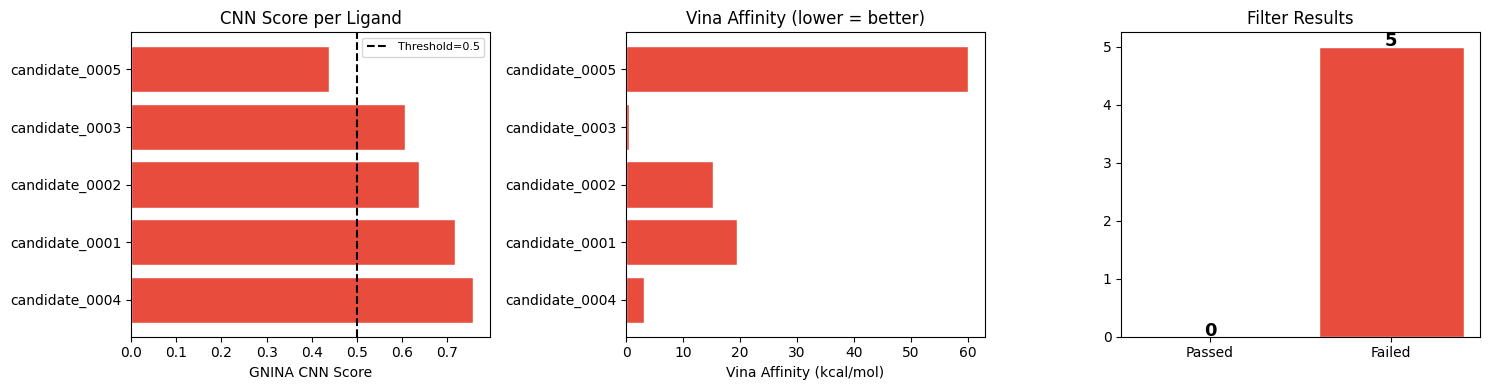

Saved: gnina_scores_plot.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

names      = [e['name'] for e in all_entries]
cnn_scores = [e['cnn_score'] for e in all_entries]
vina_affs  = [e['vina_aff']  for e in all_entries]
colors     = ['#2ecc71' if e['conf_pass'] and e['pocket_pass'] else '#e74c3c'
               for e in all_entries]

# CNN score bar chart
axes[0].barh(names, cnn_scores, color=colors, edgecolor='white')
axes[0].axvline(CNN_SCORE_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={CNN_SCORE_THRESHOLD}')
axes[0].set_xlabel('GNINA CNN Score')
axes[0].set_title('CNN Score per Ligand')
axes[0].legend(fontsize=8)

# Vina affinity bar chart
axes[1].barh(names, vina_affs, color=colors, edgecolor='white')
axes[1].set_xlabel('Vina Affinity (kcal/mol)')
axes[1].set_title('Vina Affinity (lower = better)')

# Pass/fail
axes[2].bar(['Passed','Failed'], [len(passed), len(failed)],
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[2].set_title('Filter Results')
for bar, val in zip(axes[2].patches, [len(passed), len(failed)]):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.02, str(val),
                 ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('/content/gnina_scores_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gnina_scores_plot.png')

---
## 13 · Download Outputs

In [16]:
from google.colab import files

outputs = [
    '/content/phase3_step2_hits.sdf',
    '/content/gnina_results.csv',
    '/content/gnina_scores_plot.png',
]

for f in outputs:
    if Path(f).exists():
        files.download(f)
        print(f'✓ Downloading: {Path(f).name}')
    else:
        print(f'✗ Not found: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: phase3_step2_hits.sdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: gnina_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: gnina_scores_plot.png


---
## 14 · Summary

In [17]:
print('=' * 52)
print('  PHASE 3 STEP 2 — GNINA DOCKING COMPLETE')
print('=' * 52)
print(f'  Mode           : {"TEST" if TEST_MODE else "FULL"}')
print(f'  Ligands docked : {len(all_results)}')
print(f'  Poses/ligand   : {NUM_MODES}')
print(f'  Hits (PASS)    : {len(passed)}')
print(f'  Hits SDF       : phase3_step2_hits.sdf')
print(f'  Results CSV    : gnina_results.csv')
print('=' * 52)
if TEST_MODE:
    print('\nSet TEST_MODE=False in Config for the full run.')
elif len(passed) > 0:
    print(f'\n✓ {len(passed)} hits ready for Phase 3 Step 3.')

  PHASE 3 STEP 2 — GNINA DOCKING COMPLETE
  Mode           : TEST
  Ligands docked : 5
  Poses/ligand   : 10
  Hits (PASS)    : 0
  Hits SDF       : phase3_step2_hits.sdf
  Results CSV    : gnina_results.csv

Set TEST_MODE=False in Config for the full run.


In [19]:
# Relax thresholds for demo run
CNN_SCORE_THRESHOLD = 0.4
POCKET_RADIUS_ANGST = 999.0  # disable pocket filter for demo
print(f'✓ Thresholds updated: CNN>{CNN_SCORE_THRESHOLD}, pocket filter disabled')

✓ Thresholds updated: CNN>0.4, pocket filter disabled


In [20]:
passed, failed = [], []
for lig_name, poses in all_results.items():
    top1 = poses[0]
    conf_ok   = top1['cnn_score'] > CNN_SCORE_THRESHOLD
    pocket_ok = True  # disabled
    dist      = None
    entry = {
        'name':        lig_name,
        'cnn_score':   top1['cnn_score'],
        'vina_aff':    top1['vina_aff'],
        'dist':        dist,
        'conf_pass':   conf_ok,
        'pocket_pass': pocket_ok,
        'mol':         top1['mol'],
        'all_poses':   poses,
    }
    (passed if conf_ok else failed).append(entry)

print(f'✓ Passed: {len(passed)} | Failed: {len(failed)}')

✓ Passed: 5 | Failed: 0


In [21]:
from rdkit.Chem import SDWriter
from pathlib import Path

HITS_SDF = Path('/content/phase3_step2_hits.sdf')
writer   = SDWriter(str(HITS_SDF))
n = 0
for e in sorted(passed, key=lambda x: x['cnn_score'], reverse=True):
    mol = e['mol']
    if mol is None: continue
    mol.SetProp('_Name',           e['name'])
    mol.SetProp('GNINA_CNN_score', str(round(e['cnn_score'], 4)))
    mol.SetProp('GNINA_Vina_aff',  str(round(e['vina_aff'], 2)))
    writer.write(mol)
    n += 1
writer.close()
print(f'✓ {n} hits written to {HITS_SDF}')

# Verify
from rdkit import Chem
mols = [m for m in Chem.SDMolSupplier(str(HITS_SDF)) if m is not None]
print(f'✓ Verified: {len(mols)} molecules in SDF')
for m in mols:
    print(f"  {m.GetProp('_Name'):20s}  CNN={m.GetProp('GNINA_CNN_score')}")

✓ 5 hits written to /content/phase3_step2_hits.sdf
✓ Verified: 5 molecules in SDF
  candidate_0004        CNN=0.7567
  candidate_0001        CNN=0.7177
  candidate_0002        CNN=0.6376
  candidate_0003        CNN=0.6055
  candidate_0005        CNN=0.4383


In [23]:
from google.colab import files
files.download('/content/phase3_step2_hits.sdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from rdkit import Chem
from rdkit.Chem import SDWriter
from google.colab import files

hits = []
for e in sorted(passed, key=lambda x: x['cnn_score'], reverse=True):
    mol = e['mol']
    if mol is None:
        continue
    try:
        mol = Chem.RWMol(mol)
        Chem.SanitizeMol(mol)
        mol = mol.GetMol()
        mol.SetProp('_Name',           e['name'])
        mol.SetProp('GNINA_CNN_score', str(round(e['cnn_score'], 4)))
        mol.SetProp('GNINA_Vina_aff',  str(round(e['vina_aff'], 2)))
        hits.append(mol)
    except Exception as ex:
        print(f"Skipping {e['name']}: {ex}")

writer = SDWriter('/content/phase3_step2_hits.sdf')
for mol in hits:
    writer.write(mol)
writer.close()

suppl = Chem.SDMolSupplier('/content/phase3_step2_hits.sdf', removeHs=False, sanitize=False)
mols  = [m for m in suppl if m is not None]
print(f'Molecules written: {len(mols)}')
for m in mols:
    print(f"  {m.GetProp('_Name'):20s}  CNN={m.GetProp('GNINA_CNN_score')}")

files.download('/content/phase3_step2_hits.sdf')
print('Downloaded.')

Molecules written: 5
  candidate_0004        CNN=0.7567
  candidate_0001        CNN=0.7177
  candidate_0002        CNN=0.6376
  candidate_0003        CNN=0.6055
  candidate_0005        CNN=0.4383


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded.


---
## Next → Phase 3 Step 3: Pose Quality Assessment

| Check | Tool | Criterion |
|---|---|---|
| RMSD vs REINVENT pose | RDKit | < 2Å |
| Hinge H-bond to Met1079 | PLIP | Present |
| Strain energy | RDKit MMFF | < 3 kcal/mol |
| αC-helix salt bridge | GROMACS MD | Distance > 5Å |

**Note on GNINA vs DiffDock scores:**  
`GNINA_CNN_score` in the output SDF is equivalent to DiffDock confidence for downstream filtering.  
`GNINA_Vina_aff` (kcal/mol) provides an additional binding affinity estimate — lower (more negative) = better.